## Завантаження і первинний огляд даних

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import yaml

with open("./config/configs.yaml", "r") as f:
    config = yaml.safe_load(f)

db_path = config["data"]["db_path"]

# Підключення до БД
conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM credit_data", conn)

**Перші 10 записів**

In [4]:
display(df.head(10))

,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default,avg_delay,max_delay,total_bill,total_paid,payment_ratio
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,1,-0.333333,2,7704,689,0.089422
1,120000,2,2,2,26,-1,2,0,0,0,...,1000,1000,0,2000,1,0.500000,2,17077,5000,0.292774
2,90000,2,2,2,34,0,0,0,0,0,...,1000,1000,1000,5000,0,0.000000,0,101653,11018,0.108387
3,50000,2,2,1,37,0,0,0,0,0,...,1200,1100,1069,1000,0,0.000000,0,231334,8388,0.036259
4,50000,1,2,1,57,-1,0,-1,0,0,...,10000,9000,689,679,0,-0.333333,0,109339,59049,0.540049
5,50000,1,1,2,37,0,0,0,0,0,...,657,1000,1000,800,0,0.000000,0,238114,7772,0.032640
6,500000,1,1,2,29,0,0,0,0,0,...,38000,20239,13750,13770,0,0.000000,0,2724595,180759,0.066343
7,100000,2,2,2,23,0,-1,-1,0,0,...,0,581,1687,1542,0,-0.500000,0,13486,4791,0.355231
8,140000,2,3,1,28,0,0,2,0,0,...,432,1000,1000,1000,0,0.333333,2,65212,6761,0.103676
9,20000,1,3,2,35,-2,-2,-2,-2,-1,...,0,13007,1122,0,0,-1.666667,-1,26919,14129,0.524851


**Назви колонок та розмір датасету**

In [5]:
print(f"Список колонок: {df.columns.to_numpy()}")
print(f"\n Розмір датасету: {df.shape}")

Список колонок: ['limit_bal' 'sex' 'education' 'marriage' 'age' 'pay_0' 'pay_2' 'pay_3'
 'pay_4' 'pay_5' 'pay_6' 'bill_amt1' 'bill_amt2' 'bill_amt3' 'bill_amt4'
 'bill_amt5' 'bill_amt6' 'pay_amt1' 'pay_amt2' 'pay_amt3' 'pay_amt4'
 'pay_amt5' 'pay_amt6' 'default' 'avg_delay' 'max_delay' 'total_bill'
 'total_paid' 'payment_ratio']

 Розмір датасету: (30000, 29)


**Основна інформація про датасет**

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   limit_bal      30000 non-null  int64  
 1   sex            30000 non-null  int64  
 2   education      30000 non-null  int64  
 3   marriage       30000 non-null  int64  
 4   age            30000 non-null  int64  
 5   pay_0          30000 non-null  int64  
 6   pay_2          30000 non-null  int64  
 7   pay_3          30000 non-null  int64  
 8   pay_4          30000 non-null  int64  
 9   pay_5          30000 non-null  int64  
 10  pay_6          30000 non-null  int64  
 11  bill_amt1      30000 non-null  int64  
 12  bill_amt2      30000 non-null  int64  
 13  bill_amt3      30000 non-null  int64  
 14  bill_amt4      30000 non-null  int64  
 15  bill_amt5      30000 non-null  int64  
 16  bill_amt6      30000 non-null  int64  
 17  pay_amt1       30000 non-null  int64  
 18  pay_am

In [7]:
display(df.describe(include='all'))

,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default,avg_delay,max_delay,total_bill,total_paid,payment_ratio
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,3.000000e+04,30000.000000
mean,167484.322667,1.603733,1.842267,1.557267,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,5225.68150,4826.076867,4799.387633,5215.502567,0.221200,-0.182439,0.438733,2.698617e+05,3.165139e+04,21.039708
std,129747.661567,0.489129,0.744494,0.521405,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,17606.96147,15666.159744,15278.305679,17777.465775,0.415062,0.982176,1.345154,3.795643e+05,6.082768e+04,1255.771376
min,10000.000000,1.000000,1.000000,1.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,-2.000000,-2.000000,-3.362590e+05,0.000000e+00,-589.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,390.00000,296.000000,252.500000,117.750000,0.000000,-0.833333,0.000000,2.868800e+04,6.679750e+03,0.041073
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1800.00000,1500.000000,1500.000000,1500.000000,0.000000,0.000000,0.000000,1.263110e+05,1.438300e+04,0.086192
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4505.00000,4013.250000,4031.500000,4000.000000,0.000000,0.000000,2.000000,3.426265e+05,3.350350e+04,0.598218
max,1000000.000000,2.000000,4.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,896040.00000,621000.000000,426529.000000,528666.000000,1.000000,6.000000,8.000000,5.263883e+06,3.764066e+06,162000.000000


## Аналіз повноти та якості даних

In [8]:
# Перевірка на пропущені значення
missing_data = df.isnull().sum()
missing_table = pd.DataFrame({
    'Feature': missing_data.index,
    'Missing Values': missing_data.values,
    'Percentage (%)': (missing_data.values / len(df)) * 100
})

print("Таблиця пропусків по кожній ознаці:")
display(missing_table)

# Перевірка на дублікати
duplicates_count = df.duplicated().sum()
print(f"\nКількість виявлених дублікатів: {duplicates_count}")

# Перевірка некоректних значень (приклад для категорій)
print("\nРозподіл значень у категоріальних колонках (пошук неузгодженості):")
for col in ['education', 'marriage']:
    print(f"{col}: {df[col].unique()}")

Таблиця пропусків по кожній ознаці:


,Feature,Missing Values,Percentage (%)
0,limit_bal,0,0.0
1,sex,0,0.0
2,education,0,0.0
3,marriage,0,0.0
4,age,0,0.0
5,pay_0,0,0.0
6,pay_2,0,0.0
7,pay_3,0,0.0
8,pay_4,0,0.0
9,pay_5,0,0.0



Кількість виявлених дублікатів: 35

Розподіл значень у категоріальних колонках (пошук неузгодженості):
education: [2 1 3 4]
marriage: [1 2 3]


**Проміжні висновки** </br>
Набір даних є повним і не містить пропущених значень у жодній з колонок. Найбільш проблемними аспектами є технічні дублікати та наявність викидів у числових показниках. </br>
</br>
Дублікати: Виявлено 35 ідентичних записів. </br>
Категоріальна узгодженість: 
- Education: Значення (1, 2, 3, 4) відповідають стандарту (Магістр, Бакалавр, Школа, Інше).
- Marriage: Значення (1, 2, 3) є коректними (Одружений, Неодружений, Інше).

**Оцінка придатності датасету** </br>
Датасет не можна використовувати без додаткового очищення. Хоча структура даних виглядає цілісною, наявність дублікатів та екстремальних викидів у сумах платежів може призвести до некоректного навчання алгоритмів.

**Перелік ризиків для подальшого моделювання** </br> 
1. **Спотворення через дублікати**: Наявність ідентичних рядків може призвести до того, що під час розбиття на навчальну та тестову вибірки однакові дані потраплять в обидві групи. Це спричинить ефект "витоку даних" (data leakage) та штучно завищить метрики якості.

2. **Вплив викидів у платіжних даних**: Ознаки bill_amt та pay_amt містять аномально великі значення. Без логарифмування або масштабування ці ознаки можуть домінувати над іншими, що негативно вплине на лінійні моделі та методи на основі відстаней (наприклад, KNN).

3. **Дисбаланс цільової змінної**: Оскільки кількість випадків дефолту значно менша за кількість успішних виплат, існує ризик, що модель буде схильна завжди прогнозувати "0" (відсутність дефолту), ігноруючи критично важливі для бізнесу випадки ризику.

## Одновимірний аналіз ознак

У цьому розділі проводиться детальний аналіз кожної ключової ознаки окремо для розуміння розподілу значень, виявлення аномалій та оцінки дисбалансу класів

### Аналіз числових ознак

In [9]:
# Вибираємо ключові числові ознаки для аналізу
num_features = ['limit_bal', 'age', 'avg_delay', 'payment_ratio']

# Розрахунок описової статистики
num_stats = df[num_features].describe().T
num_stats['median'] = df[num_features].median()

# Вибір потрібних метрик у правильному порядку
num_stats = num_stats[['min', 'max', 'mean', 'median', 'std', '25%', '50%', '75%']]
print("Описова статистика числових ознак:")
display(num_stats)

Описова статистика числових ознак:


,min,max,mean,median,std,25%,50%,75%
limit_bal,10000.0,1000000.0,167484.322667,140000.000000,129747.661567,50000.000000,140000.000000,240000.000000
age,21.0,79.0,35.485500,34.000000,9.217904,28.000000,34.000000,41.000000
avg_delay,-2.0,6.0,-0.182439,0.000000,0.982176,-0.833333,0.000000,0.000000
payment_ratio,-589.0,162000.0,21.039708,0.086192,1255.771376,0.041073,0.086192,0.598218


**Візуалізація**

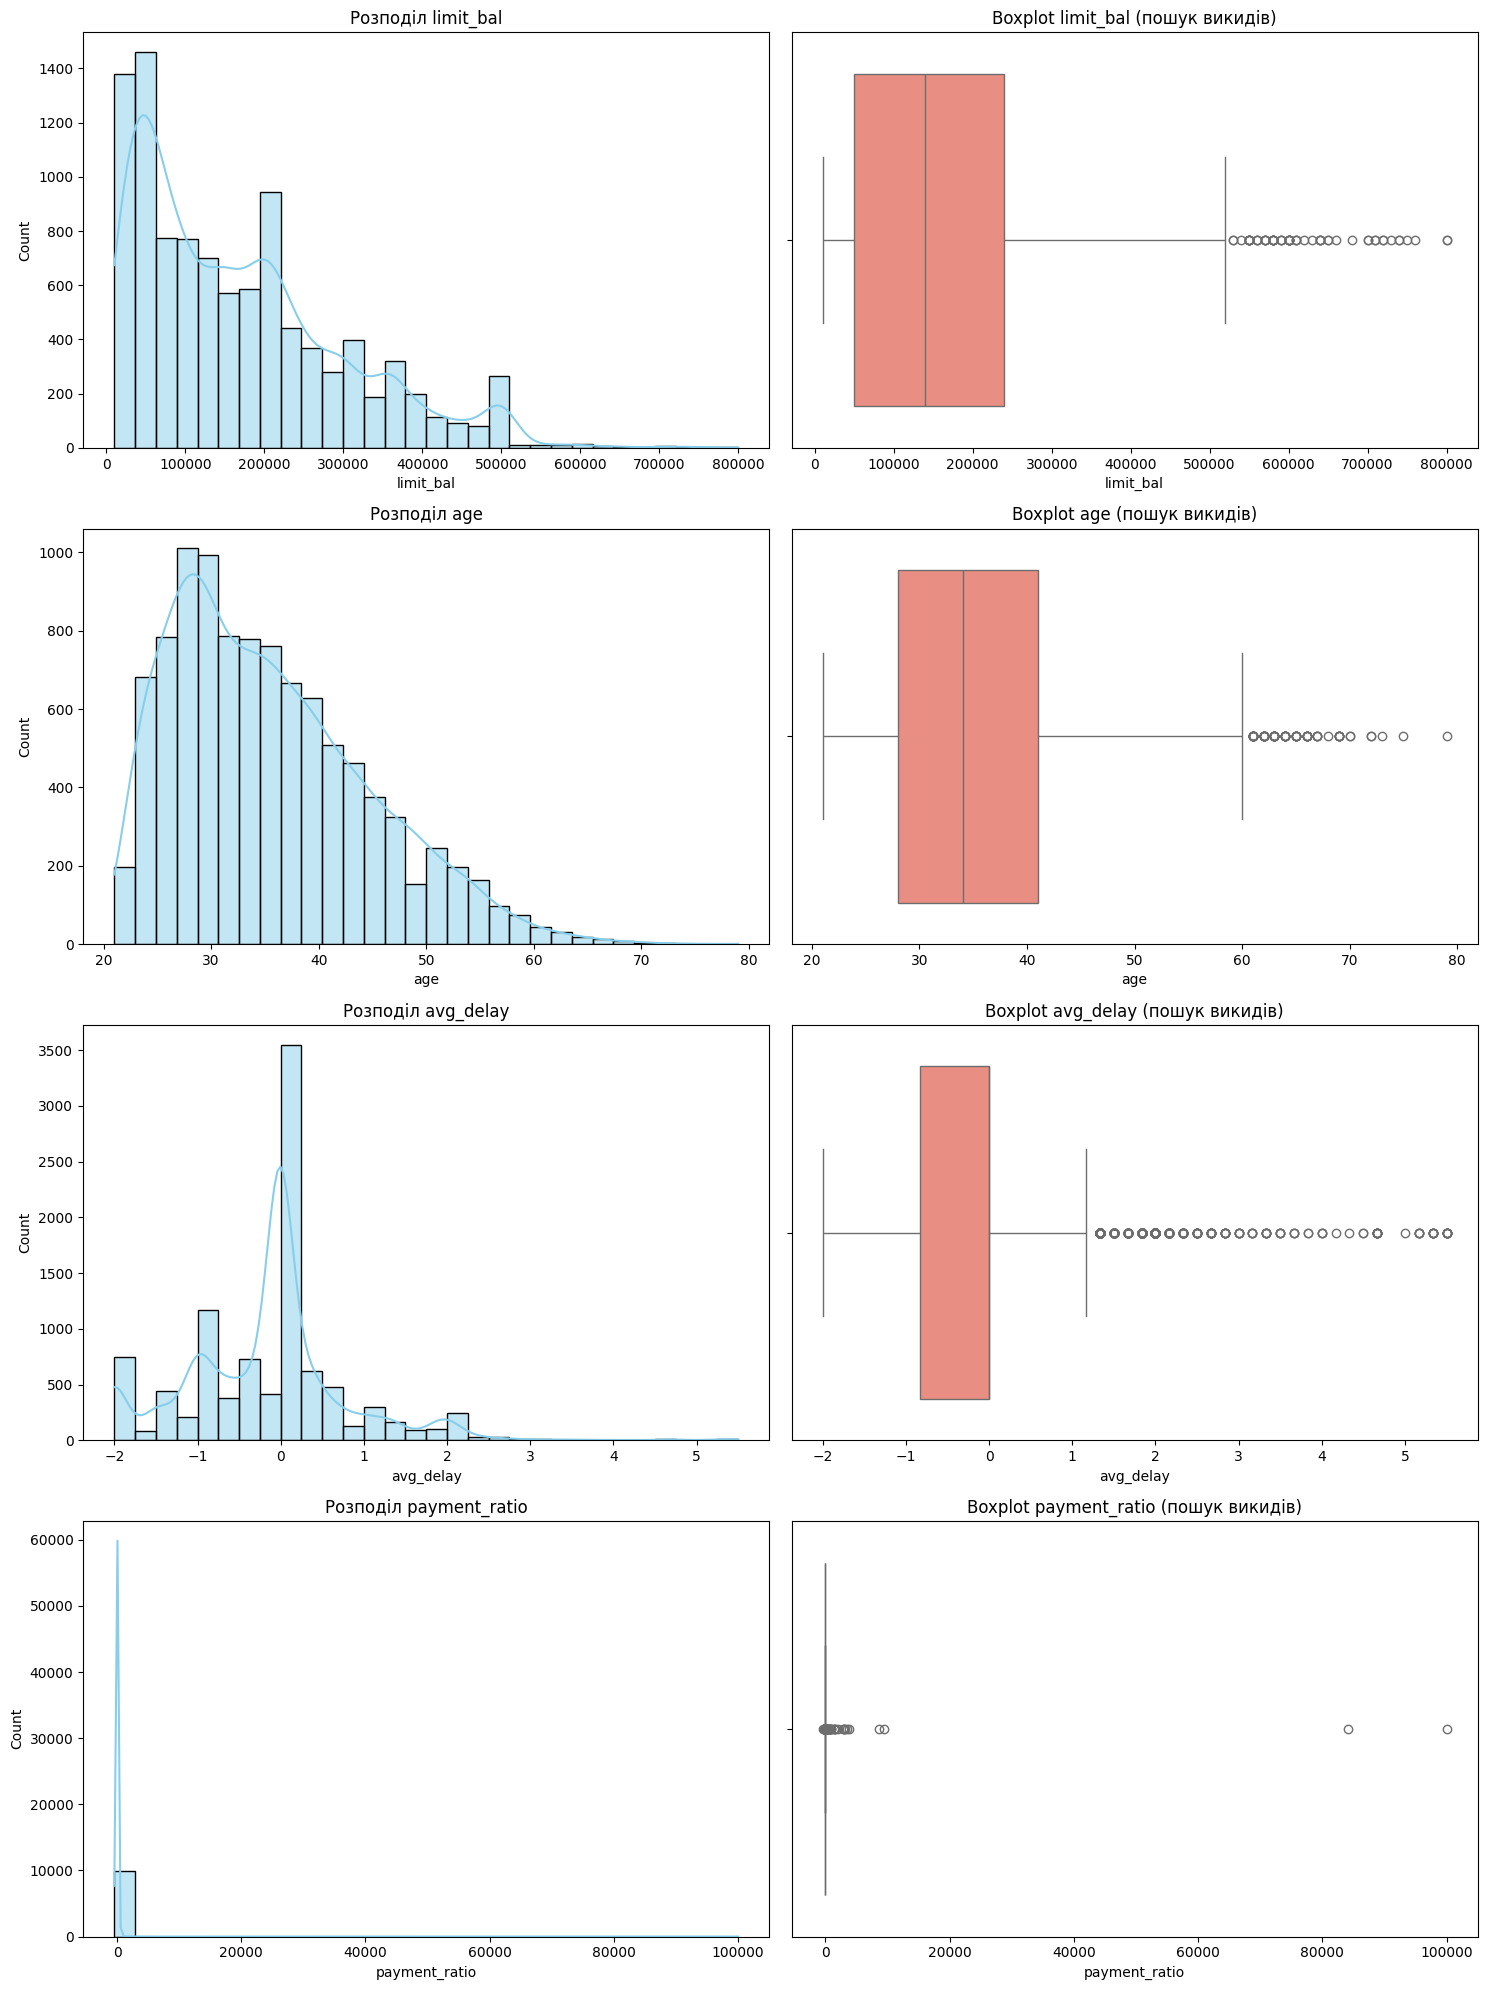

In [10]:
fig, axes = plt.subplots(len(num_features), 2, figsize=(15, 5 * len(num_features)))

# Використовуємо випадкову вибірку для прискорення графіків
df_sample = df.sample(n=10000, random_state=42)

for i, col in enumerate(num_features):
    # Гістограма розподілу
    sns.histplot(df_sample[col], kde=True, ax=axes[i, 0], color='skyblue', bins=30)
    axes[i, 0].set_title(f'Розподіл {col}')
    
    # Boxplot для виявлення викидів
    sns.boxplot(x=df_sample[col], ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'Boxplot {col} (пошук викидів)')

plt.tight_layout()
plt.show()

### Аналіз категоріальних ознак


--- Аналіз ознаки: sex ---


,Кількість,Відсоток (%)
sex,,
Female,18112,60.373333
Male,11888,39.626667



--- Аналіз ознаки: education ---


,Кількість,Відсоток (%)
education,,
University,14030,46.766667
Graduate School,10585,35.283333
High School,4917,16.390000
Others,468,1.560000



--- Аналіз ознаки: marriage ---


,Кількість,Відсоток (%)
marriage,,
Single,15964,53.213333
Married,13659,45.530000
Others,377,1.256667



--- Аналіз ознаки: default ---


,Кількість,Відсоток (%)
default,,
No,23364,77.88
Yes,6636,22.12


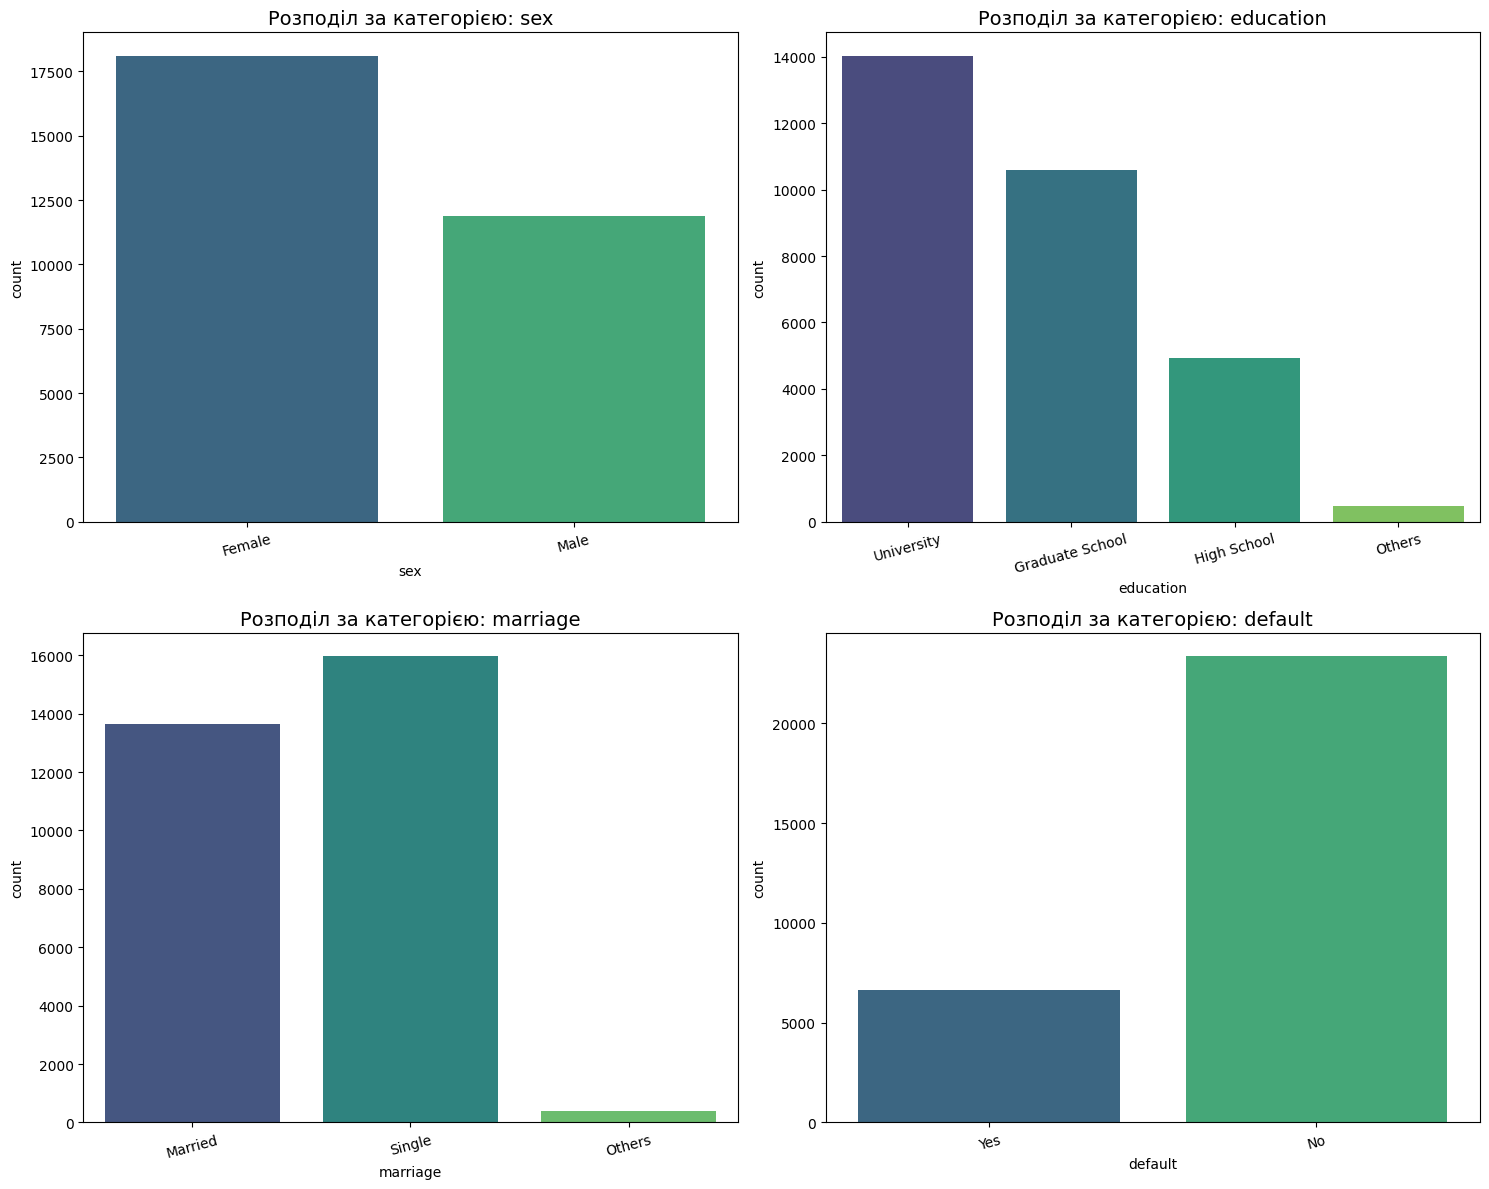

In [11]:
# Аналіз категоріальних змінних та цільової змінної
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Створюємо словники відображення на основі наданої специфікації
mapping = {
    'sex': {1: 'Male', 2: 'Female'},
    'education': {1: 'Graduate School', 2: 'University', 3: 'High School', 4: 'Others'},
    'marriage': {1: 'Married', 2: 'Single', 3: 'Others'},
    'default': {0: 'No', 1: 'Yes'}
}

# Робимо копію для візуалізації, щоб не змінювати оригінальний df
df_plot = df.copy()

# Застосовуємо "if-else" логіку через .map() для кожної категорії
for col, map_dict in mapping.items():
    if col in df_plot.columns:
        df_plot[col] = df_plot[col].map(map_dict)

# 4. Аналіз та візуалізація
cat_features = ['sex', 'education', 'marriage', 'default']

plt.figure(figsize=(15, 12))
for i, col in enumerate(cat_features):
    # Текстовий аналіз 
    print(f"\n--- Аналіз ознаки: {col} ---")
    counts = df_plot[col].value_counts()
    percentages = df_plot[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Кількість': counts, 'Відсоток (%)': percentages})
    display(summary)

    # Графічний аналіз
    plt.subplot(2, 2, i+1)
    sns.countplot(x=col, data=df_plot, palette='viridis', hue=col, legend=False)
    plt.title(f'Розподіл за категорією: {col}', fontsize=14)
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

**Проміжні висновки** </br>
**Числові ознаки**: Ознаки limit_bal та age мають правосторонній скос. Виявлено значну кількість викидів у payment_ratio. </br>
**Категоріальні ознаки**: Спостерігається дисбаланс у цільовій змінній default (співвідношення ~78/22).</br>
**Якість**: Ознака education містить рідкісні класи (0, 5, 6), які доцільно об'єднати.

## Двовимірний та багатовимірний аналіз

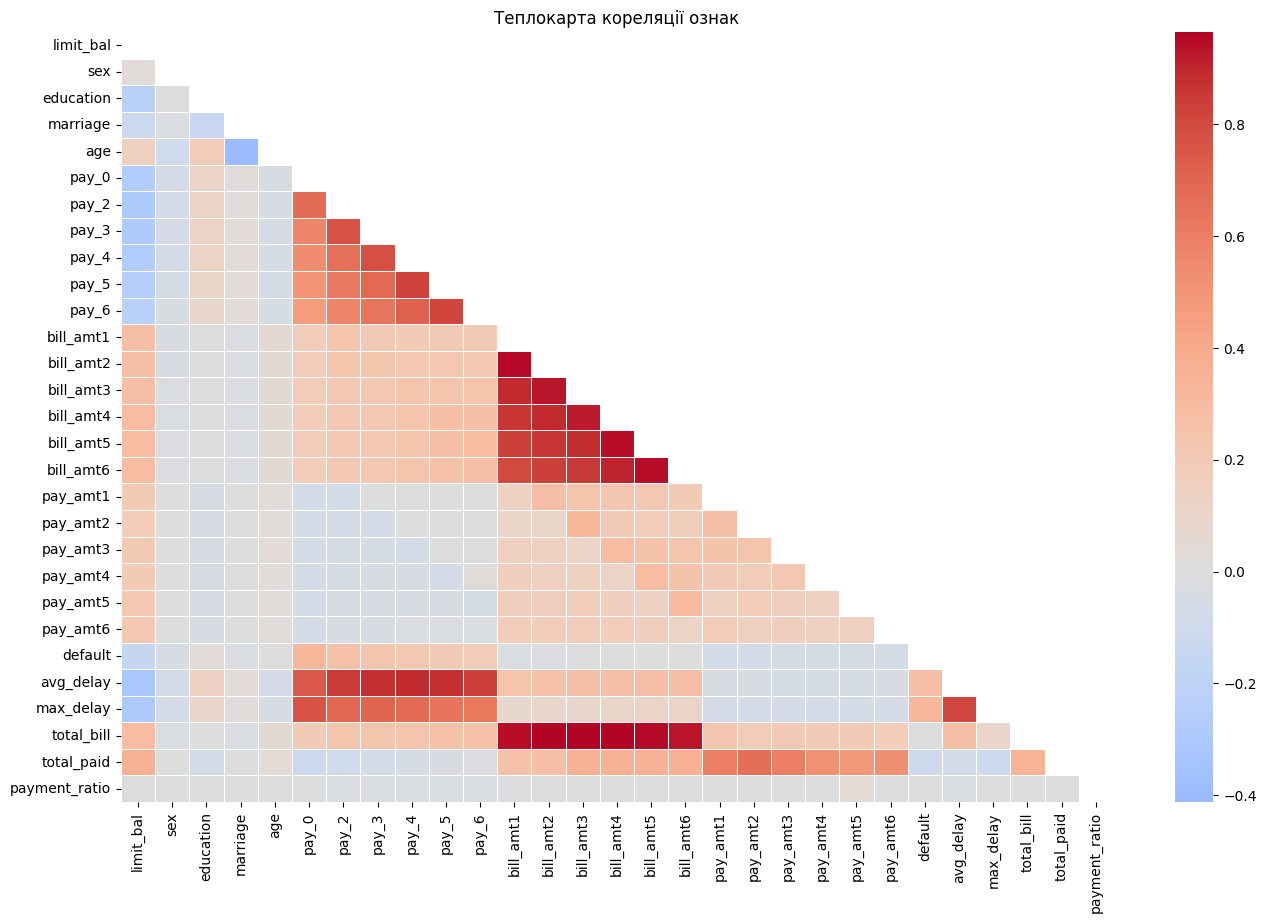

Кореляція ознак із цільовою змінною (default):
default          1.000000
max_delay        0.331036
pay_0            0.324794
avg_delay        0.281955
pay_2            0.263551
pay_3            0.235253
pay_4            0.216614
pay_5            0.204149
pay_6            0.186866
education        0.033842
age              0.013890
bill_amt6       -0.005372
bill_amt5       -0.006760
payment_ratio   -0.006892
bill_amt4       -0.010156
total_bill      -0.012691
bill_amt3       -0.014076
bill_amt2       -0.014193
bill_amt1       -0.019644
marriage        -0.027575
sex             -0.039961
pay_amt6        -0.053183
pay_amt5        -0.055124
pay_amt3        -0.056250
pay_amt4        -0.056827
pay_amt2        -0.058579
pay_amt1        -0.072929
total_paid      -0.102354
limit_bal       -0.153520
Name: default, dtype: float64


In [12]:
# Побудова матриці кореляції
plt.figure(figsize=(16, 10))
corr_matrix = df.corr()

# Створення маски для верхнього трикутника (щоб не дублювати дані)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Теплокарта кореляції ознак')
plt.show()

# Вивід кореляції з цільовою змінною
print("Кореляція ознак із цільовою змінною (default):")
print(corr_matrix['default'].sort_values(ascending=False))

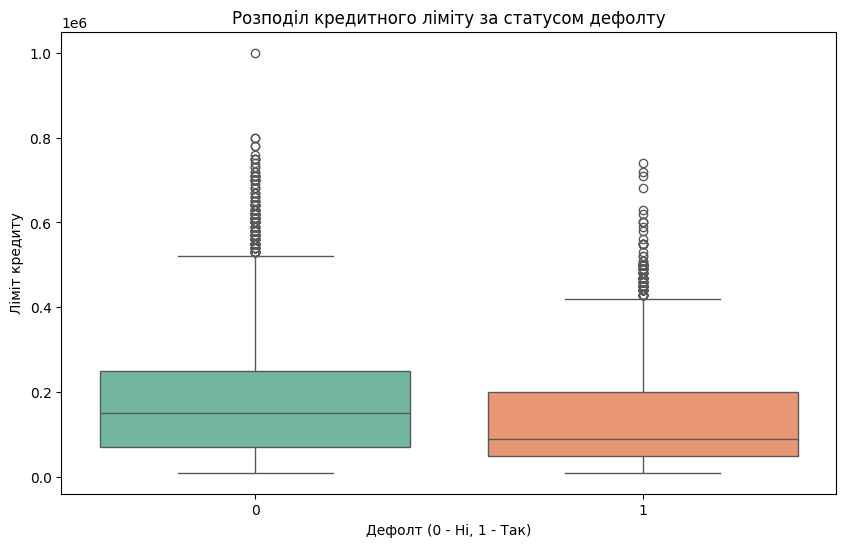

In [13]:
# Порівняння ліміту кредиту для різних класів дефолту
plt.figure(figsize=(10, 6))
sns.boxplot(x='default', y='limit_bal', data=df, palette='Set2', hue='default', legend=False)
plt.title('Розподіл кредитного ліміту за статусом дефолту')
plt.xlabel('Дефолт (0 - Ні, 1 - Так)')
plt.ylabel('Ліміт кредиту')
plt.show()

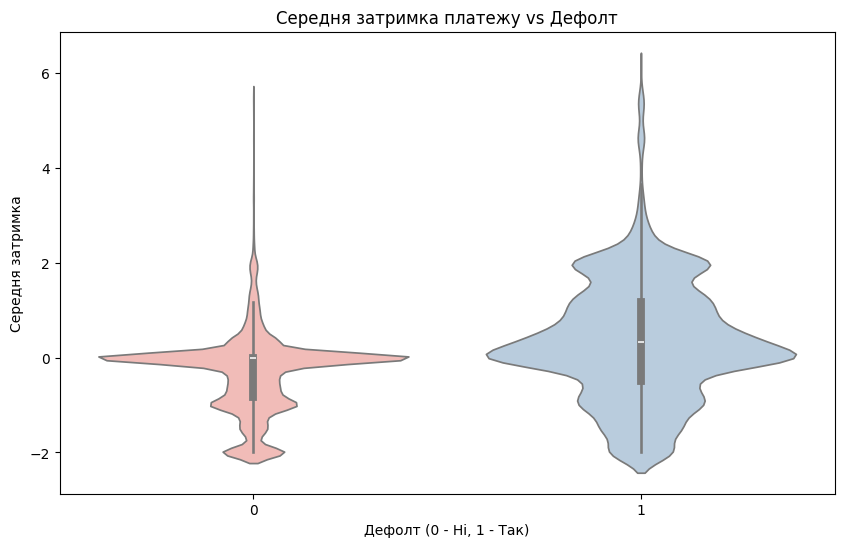

In [14]:
# Аналіз середньої затримки платежу
plt.figure(figsize=(10, 6))
sns.violinplot(x='default', y='avg_delay', data=df, palette='Pastel1', hue='default', legend=False)
plt.title('Середня затримка платежу vs Дефолт')
plt.xlabel('Дефолт (0 - Ні, 1 - Так)')
plt.ylabel('Середня затримка')
plt.show()

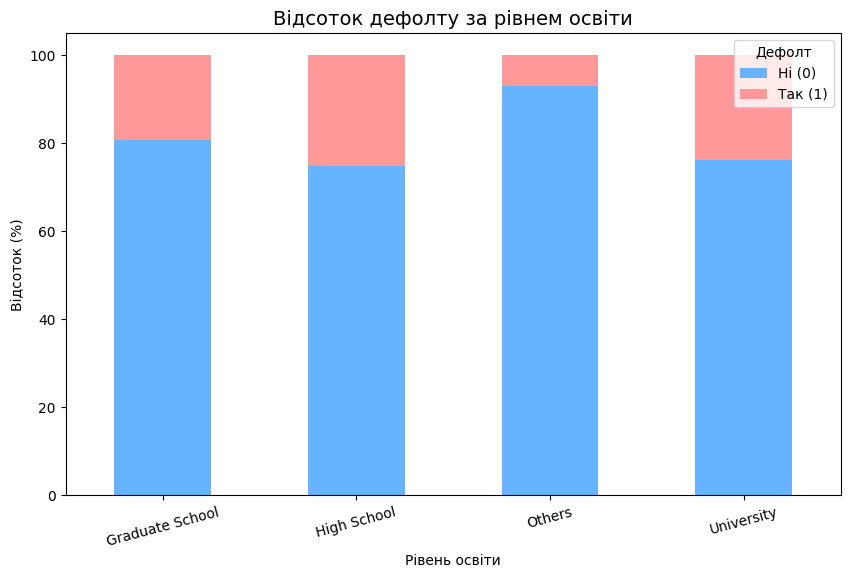

In [15]:
# Словник для відображення назв категорій
edu_map = {
    1: 'Graduate School', 
    2: 'University', 
    3: 'High School', 
    4: 'Others'
}

education_default = pd.crosstab(
    df['education'].map(edu_map), 
    df['default'], 
    normalize='index'
) * 100

# Побудова графіка
education_default.plot(
    kind='bar', 
    stacked=True, 
    figsize=(10, 6), 
    color=['#66b3ff','#ff9999']
)

plt.title('Відсоток дефолту за рівнем освіти', fontsize=14)
plt.ylabel('Відсоток (%)')
plt.xlabel('Рівень освіти')
plt.legend(title='Дефолт', labels=['Ні (0)', 'Так (1)'])
plt.xticks(rotation=15) 
plt.show()

**Проміжні висновки** </br>
**Кореляція**: Виявлено сильну мультиколінеарність між сумами рахунків (bill_amt1-6), що є логічним для часових рядів. Ознаки затримок платежів (pay_x, avg_delay) мають найсильніший позитивний зв'язок із дефолтом.</br>
**Ліміт кредиту**: Клієнти з нижчим кредитним лімітом частіше потрапляють у категорію дефолту.</br>
**Освіта**: Попередній аналіз показує різну частоту дефолтів серед різних освітніх рівнів, що робить цю ознаку корисною для моделювання.

## Аналіз цільової змінної

Розподіл класів цільової змінної:
Клас 0 (No Default): 23364 (77.88%)
Клас 1 (Default):    6636 (22.12%)


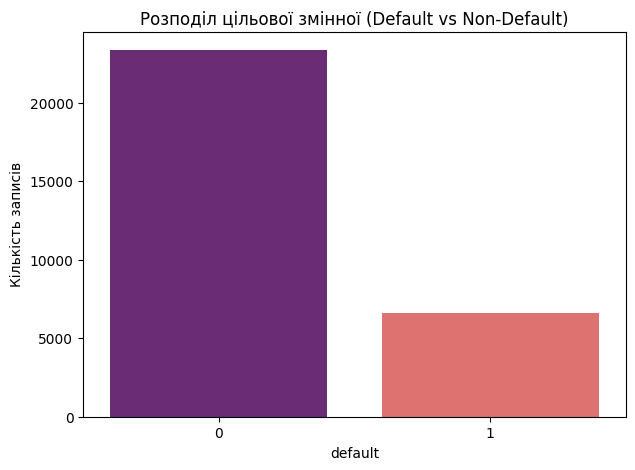

In [16]:
# Підрахунок кількості та відсоткового співвідношення
target_counts = df['default'].value_counts()
target_percent = df['default'].value_counts(normalize=True) * 100

print("Розподіл класів цільової змінної:")
print(f"Клас 0 (No Default): {target_counts[0]} ({target_percent[0]:.2f}%)")
print(f"Клас 1 (Default):    {target_counts[1]} ({target_percent[1]:.2f}%)")

# Візуалізація розподілу
plt.figure(figsize=(7, 5))
sns.countplot(x='default', data=df, hue='default', palette='magma', legend=False)
plt.title('Розподіл цільової змінної (Default vs Non-Default)')
plt.ylabel('Кількість записів')
plt.show()

**Висновки щодо вибору метрик** </br>
**Наявність дисбалансу**: У датасеті спостерігається помірний дисбаланс класів (співвідношення приблизно 1:3.5).
</br>
**Наслідки для моделювання**: Оскільки більшість клієнтів не мають дефолту, модель може показувати високу точність (Accuracy), просто ігноруючи меншість. Це неприпустимо для бізнес-задачі, де виявлення дефолтера є пріоритетним.
</br>
**Вибір метрик**: Для оцінки моделі доцільно використовувати:</br>
- **Precision/Recall**: Для оцінки якості прогнозування саме дефолтів.</br>
- **F1-Score**: Як гармонійне середнє між точністю та повнотою.</br>
- **ROC-AUC**: Для оцінки здатності моделі розділяти класи.</br>

### Формування аналітичних висновків

1. Чи придатний датасет? </br>
Так, дані достатньо повні, без пропусків та з чіткою цільовою змінною.</br>
</br>
2. Основні проблеми якості?</br>
Наявність 35 дублікатів та невеликий дисбаланс класів.</br>
</br>
3. Найбільш корисні ознаки?</br>
pay_0 (історія останнього платежу) та limit_bal.</br>
</br>
4. Наступні кроки очищення?</br>
Видалення дублікатів, групування рідкісних категорій в education та масштабування числових даних.</br>